In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed

In [4]:
#矩阵信息 
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m-4*B/(a**2))*sz

def h_x(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sx

def h_y(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= -1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A):
    TX_block=h_x(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    yshumu,Nd,    A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < yshumu-1:
            H[i][i+1] = t_y(B,a,A)

        if i > 0:
            H[i][i-1] = t_y(B,a,A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   yshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=t_x(B,a,A)

    #
    H = np.block(H)
    return H

m=-0.5
A=1
B=-0.5

delta=0.75
chaodaojiao=0
T_Tc=1e-4
Delta = delta#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
KBT=2 * delta * T_Tc / 3.5
shumu=401


a=1
N=11
yshumu=40

uN=0
uS=0.0
#uS=1


#Ey = 0.0035/yshumu*0.9#
Ey= 0.000#/yshumu*1
#Ey=0.0035/10
#Ey=0.003/100
uN_set = []
for i in range(yshumu):
    uN_set.append(uN- Ey*0* (i - yshumu/2))
uS_set=[]
for i in range(yshumu):
    uS_set.append(uS - Ey *1* (i - yshumu/2))
#uS_set=[]
#for i in range(Ny):
#    uS_set.append(uS)
#print(uN_set[99])
#print(uS_set[99])

H_q= H_onstie(m,B,a   ,uN_set,0,0,    yshumu,4,    A)
T_21= H_hop(B,a,A,   yshumu,4)#.conj().T

H_l= H_onstie(m,B,a   ,uS_set,Delta,0,    yshumu,4,    A)
T_l= H_hop(B,a,A,   yshumu,4)#.conj().T

H_r= H_onstie(m,B,a   ,uS_set,Delta,-chaodaojiao,    yshumu,4,    A)
T_r= H_hop(B,a,A,   yshumu,4).conj().T

T_LD=H_hop(B,a,A,   yshumu,4).conj().T
T_RD=H_hop(B,a,A,   yshumu,4)


if m**2<delta**2+uS**2:
    leiN=1
elif m<-(delta**2+uS**2)**0.5:
    leiN=2
elif m>(delta**2+uS**2)**0.5:
    leiN=0


#print(H_q.shape)
#保存函数（图片）
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_del={delta}_y={yshumu}_uS={uS}_Ey={Ey:.5f}"

# 清洗文件夹名称中的非法字符
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

# --- 2. 设置保存根目录 ---
# 这里会自动填充你要求的参数信息
save_dir = rf"D:\结果\2026.4.14"#\{params_str}"
os.makedirs(save_dir, exist_ok=True)

# --- 3. 修改后的保存函数 ---
def save_fig_by_title(name):
    # a. 清洗文件名（去除非法字符和 LaTeX 符号）
    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')

    # b. 构造完整路径
    filename = os.path.join(save_dir, safe_name + ".png")

    # c. 执行保存
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")

# --- 4. 使用示例 ---
save = True  # 设置为 True 才会执行保存


Calculating Bands: 100%|██████████| 601/601 [00:01<00:00, 410.31it/s]


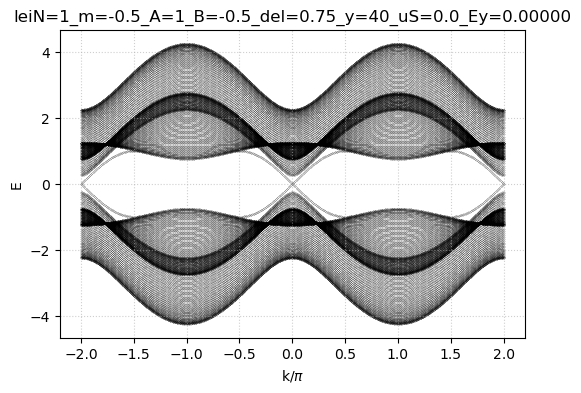

In [7]:
# 两边能带
ks1 = np.linspace(-2*np.pi, 2*np.pi, 601)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.01)
#plt.ylim(-0.5,0.5)
#plt.xlim(-0.2,0.2)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)

Calculating Bands: 100%|██████████| 101/101 [00:00<00:00, 330.04it/s]


1


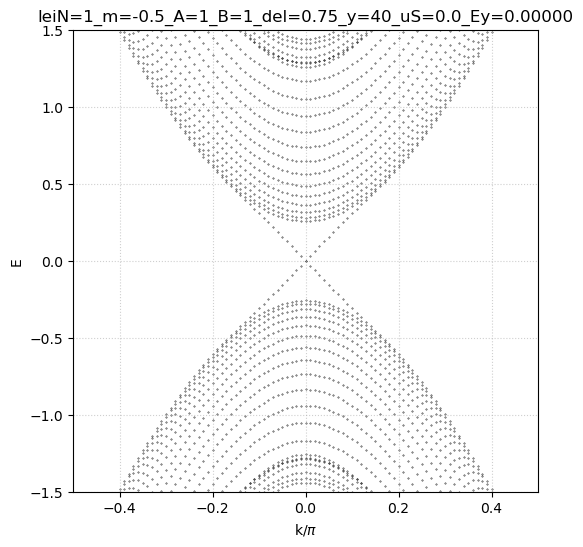

In [63]:
# 两边能带
ks1 = np.linspace(-0.5*np.pi, 0.5*np.pi,101)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
plt.ylim(-1.5,1.5)
plt.xlim(-0.5,0.5)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)
print(leiN)
plt.show()

Calculating Bands: 100%|██████████| 101/101 [00:08<00:00, 11.97it/s]


已保存图片: D:\结果\2026.4.14\leiN=0_m=0.2_A=1_B=1_del=0.1_y=101_uS=0.0_Ey=0.00000.png


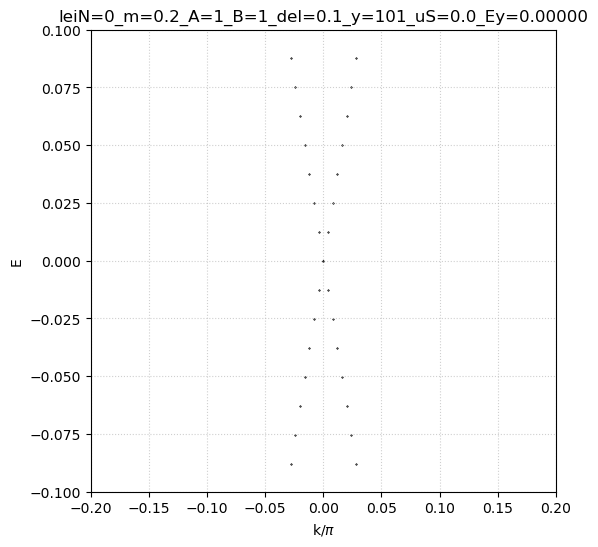

In [42]:
# 两边能带保存
ks1 = np.linspace(-0.2*np.pi, 0.2*np.pi,101)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
plt.ylim(-0.1,0.1)
plt.xlim(-0.2,0.2)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)
save_fig_by_title(params_str)
plt.show()

Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 1380.30it/s]


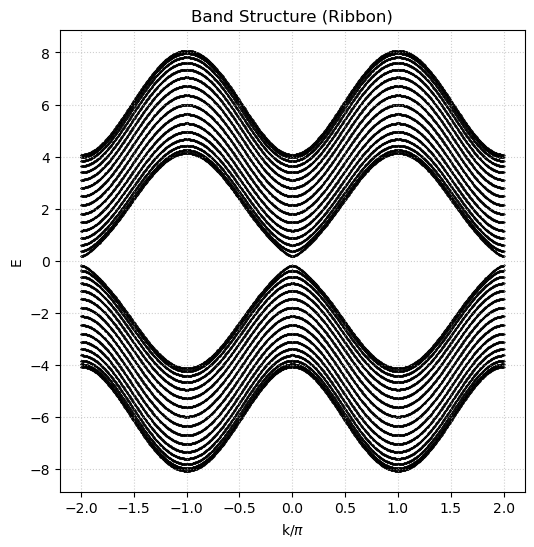

In [247]:
# 中间能带
ks = np.linspace(-2*np.pi, 2*np.pi, 1001)
#ks = np.linspace(-2*np.pi, 2*np.pi, 101)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies = []
# 使用 tqdm 显示进度条
for k in tqdm(ks, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals = np.linalg.eigvalsh(H_k)
    energies.append(evals)

energies = np.array(energies)

# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies.shape[1]):
    plt.scatter(ks/np.pi, energies[:, i], color='black', s=0.1)

#plt.ylim(-0.5,0.5)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)
#plt.savefig('band_structure.png')

Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 1430.39it/s]


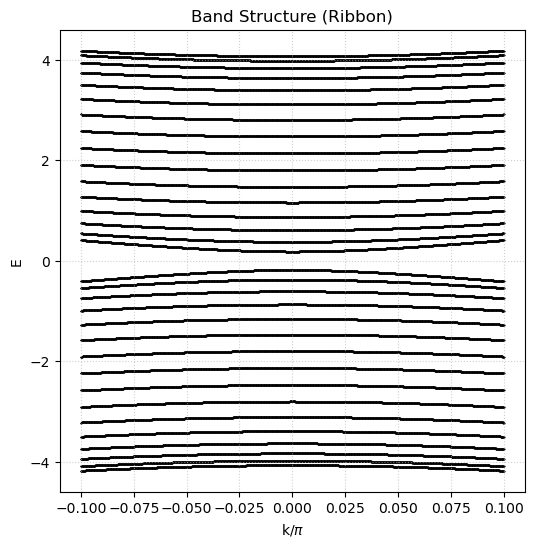

In [248]:
# 中间能带
ks = np.linspace(-0.1*np.pi, 0.1*np.pi, 1001)
#ks = np.linspace(-2*np.pi, 2*np.pi, 101)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies = []
# 使用 tqdm 显示进度条
for k in tqdm(ks, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals = np.linalg.eigvalsh(H_k)
    energies.append(evals)

energies = np.array(energies)

# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies.shape[1]):
    plt.scatter(ks/np.pi, energies[:, i], color='black', s=0.1)

#plt.ylim(-0.5,0.5)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)
#plt.savefig('band_structure.png')

In [191]:
import os
import matplotlib.patches as mpatches # 用于画图例

# ================= 6. 提取 k=0 的本征态并保存 44 分量的分布图 =================

k_target = 0.02*np.pi
# 计算 k 时的哈密顿量
H_k0 = Hk(k_target, H_r, T_r)


param_folder = f"leiN={leiN}_k={k_target:.4f}_m={m}_A={A}_B={B}_del={delta}_y={yshumu}_uS={uS}_Ey={Ey:.5f}"
save_dir = rf"D:\结果\2026.4.14\{param_folder}"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 求解本征值和本征态
evals, evecs = np.linalg.eigh(H_k0)

Nd = 4  # 你代码里定义的每个格点的自由度维度
print(f"\n开始计算 k={k_target} 的本征态波函数...")
print(f"共 {len(evals)} 个态，正在保存至 {save_dir} ...")

for i in tqdm(range(len(evals)), desc="Saving Wavefunctions"):
    E = evals[i]
    psi = evecs[:, i] 
    
    # 计算模方 |psi|^2 (这里不再使用 np.sum 去合并它们)
    prob = np.abs(psi)**2
    
    # 归一化 (总概率之和为1)
    prob = prob / np.sum(prob)
    
    # 画图：
    plt.figure(figsize=(14, 5))
    
    # 定义 4 种颜色：红(e↑), 蓝(e↓), 绿(h↑), 橙(h↓)
    color_map = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e'] 
    
    # 循环生成 柱子的颜色
    colors = [color_map[j % Nd] for j in range(yshumu * Nd)]
    
    # 画柱状图，X轴从 0 到 43
    x_positions = np.arange(yshumu * Nd)
    plt.bar(x_positions, prob, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # 画垂直的灰色虚线，把第0个格点、第1个格点...隔开，方便眼睛看
    for j in range(yshumu + 1):
        plt.axvline(x=j * Nd - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # 设置图表标题和坐标轴
    plt.title(fr"Detailed {yshumu*4}-Component Probability (k={k_target})\nE = {E:.4f}")
    plt.xlabel(fr"Component Index (0 to {4*yshumu-1})")
    plt.ylabel(r"$|\psi|^2$")
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
  
    plt.xticks(x_positions, x_positions, fontsize=7)
    plt.xlim(-1, yshumu * Nd)
    #plt.ylim(0, 0.2)
    
    labels = [r'Electron $\uparrow$ (e_up)', r'Electron $\downarrow$ (e_dn)', 
              r'Hole $\uparrow$ (h_up)', r'Hole $\downarrow$ (h_dn)']
    patches = [mpatches.Patch(color=color_map[k], label=labels[k]) for k in range(Nd)]
    plt.legend(handles=patches, loc='upper right')
    
    # 按能量本征值保留4位小数命名
    filename = f"E_{E:.4f}.png"
    filepath = os.path.join(save_dir, filename)
    
    # 保存并关闭画布
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()

print("全部图片保存完毕！")


开始计算 k=0.06283185307179587 的本征态波函数...
共 84 个态，正在保存至 D:\结果\2026.4.14\leiN=1_k=0.0628_m=0.1_A=1_B=1_del=0.05_y=21_uS=0.1_Ey=0.00400 ...


Saving Wavefunctions: 100%|██████████| 84/84 [00:37<00:00,  2.24it/s]

全部图片保存完毕！
